[*********************100%***********************]  1 of 1 completed



Note: Position still open at end of period - 550.21 shares at $250.83

Backtest result - AAPL:
Strategy SMA 20 X SMA 50 crossover
Stop Loss: 5.0% | Target: 10.0%
Period: 2020-01-01 -> 2024-12-31
Starting capital: $100000.00
Final portfolio: $138008.62
Total return: 38.01%
Buy & Hold return: 273.45%
Annualised return: 6.95%
Sharpe ratio: 0.69
Max drawdown: -21.69%
Total trades: 13
Win rate: 46.15%
Stop losses: 5
Target hits: 6
Average PnL per trade: 2.56%


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/matplotlib/cbook.py:1719: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)


Chart saved → /Users/rishavyadav/rishav_irage/backtest_report_AAPL_SL5_TGT10.png


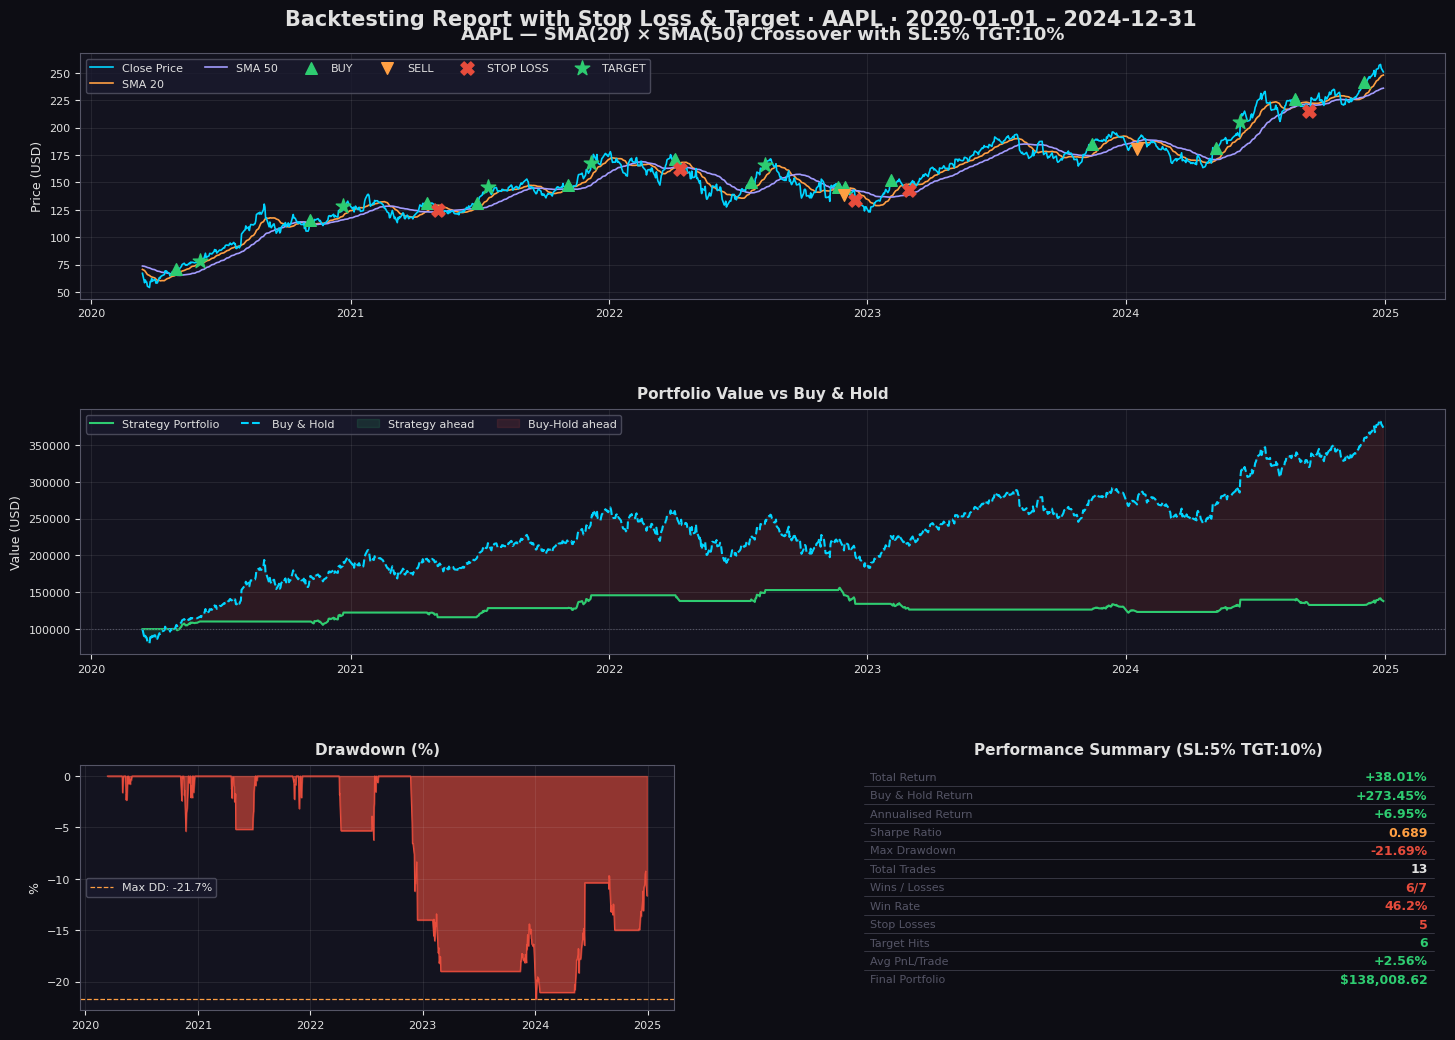

In [5]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
import os 
from datetime import datetime


# input 
stocks = input('Enter the symbol of stock: ')
start = input(f"Enter the start date (YYYY-MM-DD): ")
end = input(f"Enter the end date (YYYY-MM-DD): ")
INITIAL_CASH = int(input("Enter initial cash: "))        
SHORT_WINDOW = int(input("Enter short SMA: "))             
LONG_WINDOW  = int(input("Enter long SMA: "))
STOP_LOSS_PCT = float(input("Enter stop loss percentage (5 for 5%): ")) / 100
TARGET_PCT = float(input("Enter target percentage (10 for 10%): ")) / 100


# fetch data from y finance
data = yf.download(stocks, start, end)
df = pd.DataFrame(data)

df["SMA_short"] = df["Close"].rolling(SHORT_WINDOW).mean()
df["SMA_long"]  = df["Close"].rolling(LONG_WINDOW).mean()
df.dropna(inplace=True)


# Signal: 1 = hold long   0 = in cash
df["Signal"] = np.where(df["SMA_short"] > df["SMA_long"], 1, 0)
df["Position"] = df["Signal"].diff()   # +1 = buy -1 = sell

#backtest with stop loss and target
cash  = INITIAL_CASH
shares  = 0
portfolio = []
trade_log = []
buy_price_record = 0  
stop_loss_price = 0
target_price = 0

for date, row in df.iterrows():
    price = float(row["Close"].iloc[0])
    pos = float(row["Position"].iloc[0])

    # Check stop loss and target if we any shares
    if shares > 0:
    # Stop loss check
        if price <= stop_loss_price:
            pnl = ((price - buy_price_record) / buy_price_record * 100) if buy_price_record > 0 else 0
            cash = shares * price
            trade_log.append({"Date": date, 
                              "Action": "STOP LOSS",
                              "Price": price,
                              "Value": cash,
                              "Shares": shares,
                              "PnL": pnl})
            shares = 0
            buy_price_record = 0
            
        # target chck
        elif price >= target_price:
            pnl = ((price - buy_price_record) / buy_price_record * 100) if buy_price_record > 0 else 0
            cash = shares * price
            trade_log.append({"Date": date, 
                              "Action": "TARGET",
                              "Price": price,
                              "Value": cash,
                              "Shares": shares,
                              "PnL": pnl})
            shares = 0
            buy_price_record = 0
            
        #regular sell signal
        elif pos == -1.0:
            pnl = ((price - buy_price_record) / buy_price_record * 100) if buy_price_record > 0 else 0
            cash = shares * price
            trade_log.append({"Date": date, 
                              "Action": "SELL",
                              "Price": price,
                              "Value": cash,
                              "Shares": shares,
                              "PnL": pnl})
            shares = 0
            buy_price_record = 0

    # Buy signal (only if we don't have shares)
    if pos == 1.0 and cash > 0 and shares == 0:
        shares = cash / price
        cash = 0
        buy_price_record = price
        stop_loss_price = price * (1 - STOP_LOSS_PCT)
        target_price = price * (1 + TARGET_PCT)
        trade_log.append({"Date": date,
                          "Action": "BUY", 
                          "Price": price,
                          "Shares": shares,
                          "Stop Loss": stop_loss_price,
                          "Target": target_price})

    total = cash + shares * price
    portfolio.append(total)

df["Portfolio"] = portfolio

#   buy and hold 
df["BuyHold"] = INITIAL_CASH * (df["Close"] / df["Close"].iloc[0])


# Performance metrics
final_val = df["Portfolio"].iloc[-1]
bh_val= df["BuyHold"].iloc[-1]
total_ret= (final_val - INITIAL_CASH) / INITIAL_CASH * 100
bh_ret = (bh_val - INITIAL_CASH) / INITIAL_CASH * 100

# Annual return
n_years = len(df) / 252
ann_ret = ((final_val / INITIAL_CASH) ** (1 / n_years) - 1) * 100

# daily returns
daily_ret = df["Portfolio"].pct_change().dropna()
sharpe = (daily_ret.mean() / daily_ret.std()) * np.sqrt(252)

# drawdown
rolling_max = df["Portfolio"].cummax()
drawdown = (df["Portfolio"] - rolling_max) / rolling_max
max_dd = drawdown.min() * 100



# Win rate 
trades = pd.DataFrame(trade_log)
wins = 0
losses = 0
stop_losses = 0
target_hits = 0
total_pnl = 0

if not trades.empty and 'PnL' in trades.columns:
    for i, t in trades.iterrows():
        if pd.notna(t.get("PnL")):  
            total_pnl += t["PnL"]
            if t["PnL"] > 0:
                wins += 1
                if t.get("Action") == "TARGET":
                    target_hits += 1
            else:
                losses += 1
                if t.get("Action") == "STOP LOSS":
                    stop_losses += 1

total_trades = wins + losses
win_rate = (wins / total_trades * 100) 
avg_pnl = (total_pnl / total_trades) 

## if any open position 
if shares > 0:
    print(f"\nNote: Position still open at end of period - {shares:.2f} shares at ${price:.2f}") 


print(f"\nBacktest result - {stocks}:")
print(f"Strategy SMA {SHORT_WINDOW} X SMA {LONG_WINDOW} crossover")
print(f"Stop Loss: {STOP_LOSS_PCT*100:.1f}% | Target: {TARGET_PCT*100:.1f}%")
print(f"Period: {start} -> {end}")
print(f"Starting capital: ${INITIAL_CASH:.2f}")
print(f"Final portfolio: ${final_val:.2f}")
print(f"Total return: {total_ret:.2f}%")
print(f"Buy & Hold return: {bh_ret:.2f}%")
print(f"Annualised return: {ann_ret:.2f}%")
print(f"Sharpe ratio: {sharpe:.2f}")
print(f"Max drawdown: {max_dd:.2f}%")
print(f"Total trades: {total_trades}")
print(f"Win rate: {win_rate:.2f}%")
print(f"Stop losses: {stop_losses}")
print(f"Target hits: {target_hits}")
if total_trades > 0:
    print(f"Average PnL per trade: {avg_pnl:.2f}%")
else:
    print(f"Average PnL per trade: N/A (no closed trades)")

# Charts
BG = "#0d0d14"
CARD = "#13131f"
CYAN = "#00d4ff"
ORG = "#ff9f43"
GRN = "#2ecc71"
RED = "#e74c3c"
PRP = "#a29bfe"
WHT = "#e0e0e0"
GRY = "#555566"

fig = plt.figure(figsize=(15, 11), facecolor=BG)
gs  = gridspec.GridSpec(3, 2, figure=fig,
                        hspace=0.45,
                        wspace=0.3,
                        left=0.06, 
                        right=0.97,
                        top=0.93,
                        bottom=0.06)

ax_price  = fig.add_subplot(gs[0, :])   
ax_port   = fig.add_subplot(gs[1, :])  
ax_dd     = fig.add_subplot(gs[2, 0])   
ax_metric = fig.add_subplot(gs[2, 1])   

for ax in [ax_price, ax_port, ax_dd, ax_metric]:
    ax.set_facecolor(CARD)
    for sp in ax.spines.values():
        sp.set_edgecolor(GRY)
    ax.tick_params(colors=WHT, labelsize=8)
    ax.grid(alpha=0.08, color="#ffffff")
    

# Price and sma and signal
ax_price.plot(df.index, df["Close"], color=CYAN, lw=1.2,label="Close Price",zorder=3)
ax_price.plot(df.index, df["SMA_short"],color=ORG,lw=1.2,label=f"SMA {SHORT_WINDOW}",zorder=2)
ax_price.plot(df.index, df["SMA_long"],color=PRP, lw=1.2,label=f"SMA {LONG_WINDOW}", zorder=2)


if not trades.empty:
    buys = trades[trades["Action"] == "BUY"]
    sells = trades[trades["Action"] == "SELL"]
    stop_losses_df = trades[trades["Action"] == "STOP LOSS"]
    targets_df = trades[trades["Action"] == "TARGET"]
    
    ## find corresponding prices for markers
    buy_prices = []
    for _, buy in buys.iterrows():
        price_row = df[df.index == buy["Date"]]
        if not price_row.empty:
            buy_prices.append(price_row["Close"].iloc[0])
    
    sell_prices = []
    for _, sell in sells.iterrows():
        price_row = df[df.index == sell["Date"]]
        if not price_row.empty:
            sell_prices.append(price_row["Close"].iloc[0])
    
    stop_prices = []
    for _, stop in stop_losses_df.iterrows():
        price_row = df[df.index == stop["Date"]]
        if not price_row.empty:
            stop_prices.append(price_row["Close"].iloc[0])
    
    target_prices = []
    for i, target in targets_df.iterrows():
        price_row = df[df.index == target["Date"]]
        if not price_row.empty:
            target_prices.append(price_row["Close"].iloc[0])
    
    if buy_prices:
        ax_price.scatter(buys["Date"], buy_prices, marker="^", color=GRN, s=70, zorder=5, label="BUY")
    if sell_prices:
        ax_price.scatter(sells["Date"], sell_prices, marker="v",color=ORG, s=70,zorder=5,label="SELL")
    if stop_prices:
        ax_price.scatter(stop_losses_df["Date"], stop_prices, marker="X",color=RED, s=90, zorder=5,label="STOP LOSS")
    if target_prices:
        ax_price.scatter(targets_df["Date"], target_prices, marker="*", color=GRN, s=120, zorder=5, label="TARGET")

ax_price.set_title(f"{stocks} — SMA({SHORT_WINDOW}) × SMA({LONG_WINDOW}) Crossover with SL:{STOP_LOSS_PCT*100:.0f}% TGT:{TARGET_PCT*100:.0f}%",
                   color=WHT, fontsize=13, fontweight="bold", pad=10)
ax_price.set_ylabel("Price (USD)", color=WHT, fontsize=9)
ax_price.legend(facecolor="#1a1a2e", edgecolor=GRY, labelcolor=WHT, fontsize=8, ncol=6)

# portfolio vs buyhold 
ax_port.plot(df.index, df["Portfolio"], color=GRN,  lw=1.5, label="Strategy Portfolio")
ax_port.plot(df.index, df["BuyHold"],   color=CYAN, lw=1.5, label="Buy & Hold", linestyle="--")
ax_port.axhline(INITIAL_CASH, color=GRY, lw=0.8, linestyle=":")
ax_port.fill_between(df.index,
                     df["Portfolio"], df["BuyHold"],
                     where=df["Portfolio"] >= df["BuyHold"],
                     alpha=0.12, color=GRN, label="Strategy ahead")
ax_port.fill_between(df.index,
                     df["Portfolio"], df["BuyHold"],
                     where=df["Portfolio"] < df["BuyHold"],
                     alpha=0.12, color=RED, label="Buy-Hold ahead")
ax_port.set_title("Portfolio Value vs Buy & Hold", color=WHT, fontsize=11, fontweight="bold", pad=8)
ax_port.set_ylabel("Value (USD)", color=WHT, fontsize=9)
ax_port.legend(facecolor="#1a1a2e", edgecolor=GRY, labelcolor=WHT, fontsize=8, ncol=4)

# Drawdown
ax_dd.fill_between(df.index, drawdown * 100, 0, color=RED, alpha=0.6)
ax_dd.plot(df.index, drawdown * 100, color=RED, lw=0.8)
ax_dd.axhline(max_dd, color=ORG, lw=0.9, linestyle="--",
              label=f"Max DD: {max_dd:.1f}%")
ax_dd.set_title("Drawdown (%)", color=WHT, fontsize=11, fontweight="bold", pad=8)
ax_dd.set_ylabel("%", color=WHT, fontsize=9)
ax_dd.legend(facecolor="#1a1a2e", edgecolor=GRY, labelcolor=WHT, fontsize=8)

# Metrics card
ax_metric.axis("off")
metrics = [
    ("Total Return",f"{total_ret:+.2f}%",GRN if total_ret > 0 else RED),
    ("Buy & Hold Return",f"{bh_ret:+.2f}%", GRN if bh_ret > 0 else RED),
    ("Annualised Return",f"{ann_ret:+.2f}%",GRN if ann_ret > 0 else RED),
    ("Sharpe Ratio",f"{sharpe:.3f}", GRN if sharpe > 1 else ORG),
    ("Max Drawdown",f"{max_dd:.2f}%",RED),
    ("Total Trades",f"{total_trades}", WHT),
    ("Wins / Losses",f"{wins}/{losses}",GRN if wins >= losses else RED),
    ("Win Rate",f"{win_rate:.1f}%",GRN if win_rate >= 50 else RED),
    ("Stop Losses",f"{stop_losses}",RED),
    ("Target Hits",f"{target_hits}", GRN),
    ("Avg PnL/Trade",f"{avg_pnl:+.2f}%",GRN if avg_pnl > 0 else RED),
    ("Final Portfolio",f"${final_val:,.2f}",GRN if final_val > INITIAL_CASH else RED),
]

ax_metric.set_title(f"Performance Summary (SL:{STOP_LOSS_PCT*100:.0f}% TGT:{TARGET_PCT*100:.0f}%)", 
                    color=WHT, fontsize=11, fontweight="bold", pad=8)

for i, (label, value, color) in enumerate(metrics):
    y = 0.95 - i * 0.075
    ax_metric.text(0.03, y, label, transform=ax_metric.transAxes,
                   color=GRY, fontsize=8, va="center")
    ax_metric.text(0.97, y, value, transform=ax_metric.transAxes,
                   color=color, fontsize=9, va="center", ha="right", fontweight="bold")
    if i < len(metrics) - 1:
        ax_metric.plot([0.02, 0.98], [y - 0.035, y - 0.035],
                       color=GRY, lw=0.4, transform=ax_metric.transAxes)

fig.suptitle(f"Backtesting Report with Stop Loss & Target · {stocks} · {start} – {end}",
             color=WHT, fontsize=15, fontweight="bold", y=0.97)

# save the chart 
out = f"backtest_report_{stocks}_SL{STOP_LOSS_PCT*100:.0f}_TGT{TARGET_PCT*100:.0f}.png"  
plt.savefig(out, dpi=150, bbox_inches="tight", facecolor=BG)
print(f"Chart saved → {os.path.abspath(out)}")
plt.show()